In [1]:
%pip install pandas seaborn matplotlib numpy
%pip install openpyxl

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

file_name= 'Airline_Functionality_Matrix.xlsx'
# 1. Read all sheets into a dictionary
# This is the most efficient way to pull everything at once
all_sheets = pd.read_excel(file_name, sheet_name=None)

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


C:\Users\SG0708572\AppData\Local\Temp\ipykernel_21944\3173427248.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=market_share.values, y=market_share.index, ax=axes[0], palette='viridis')


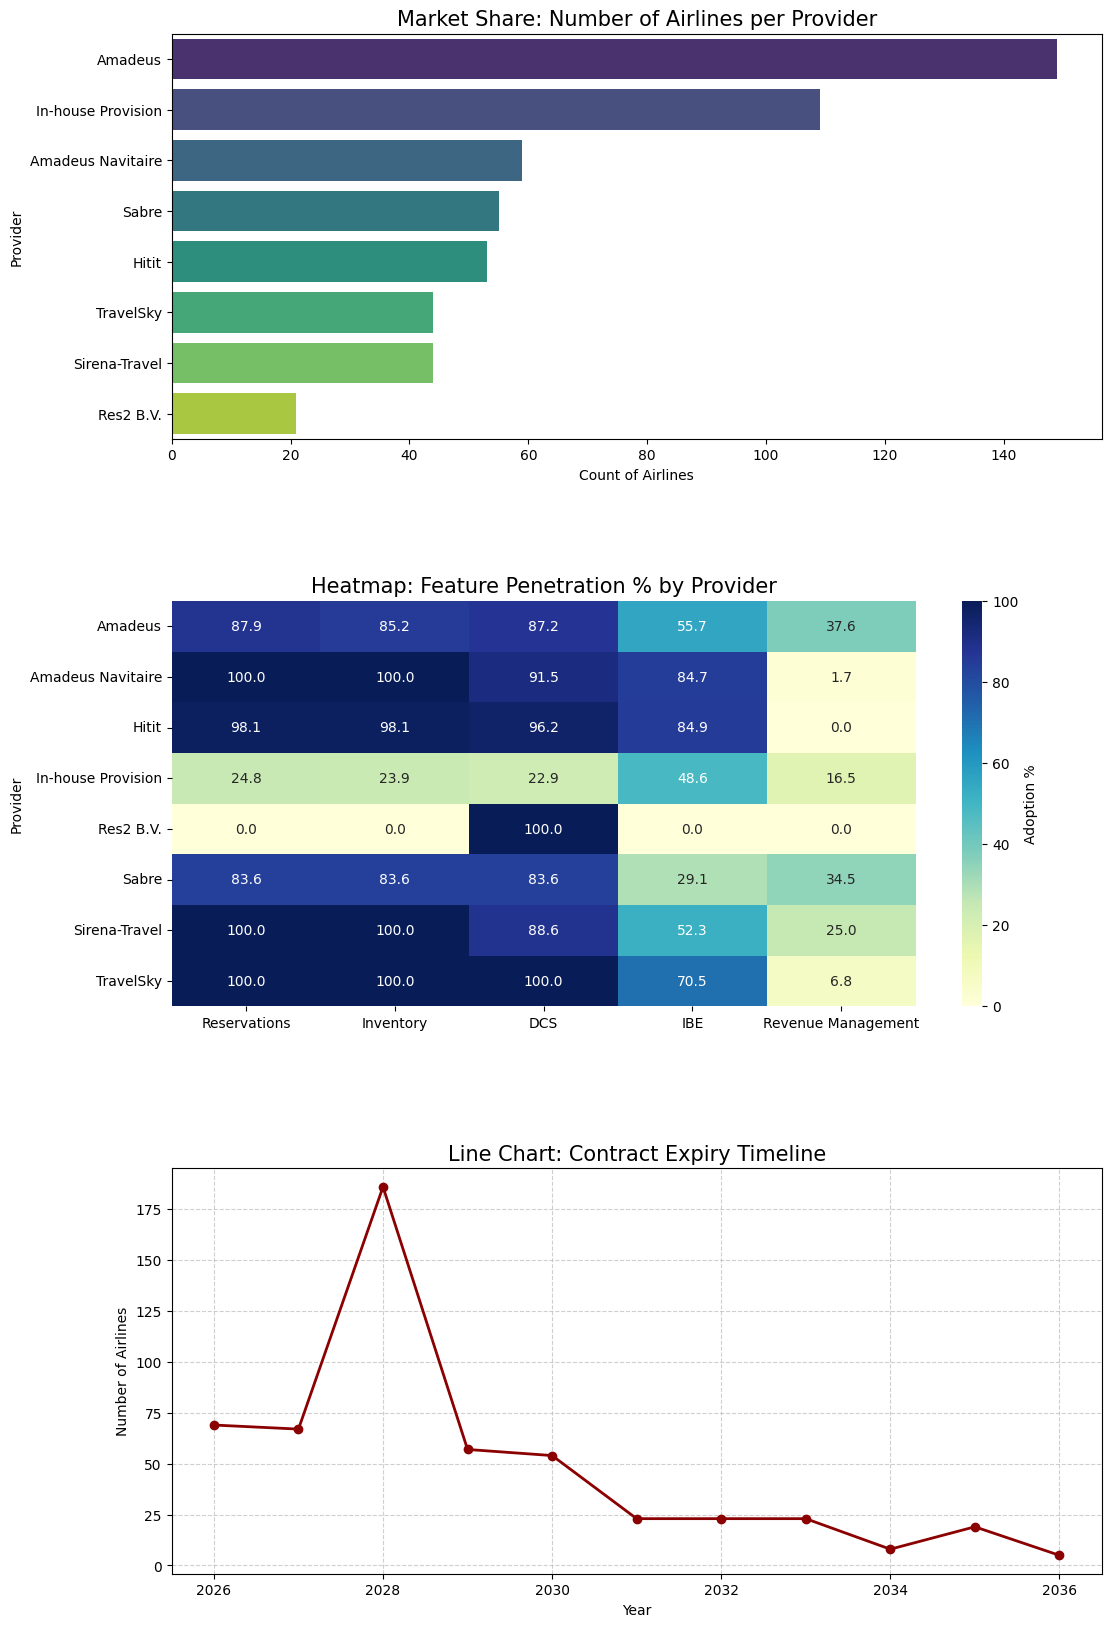

In [2]:
dfs = []
for provider_name, data in all_sheets.items():
    data['Provider'] = provider_name  # Track which provider each airline belongs to
    dfs.append(data)

df_all = pd.concat(dfs, ignore_index=True)

# Define the columns we want to analyze
features = ['Reservations', 'Inventory', 'DCS', 'IBE', 'Revenue Management']

# 2. Setup the figure for 3 charts
fig, axes = plt.subplots(3, 1, figsize=(12, 20))
plt.subplots_adjust(hspace=0.4)

# --- CHART 1: BAR CHART (Market Share) ---
market_share = df_all['Provider'].value_counts()
sns.barplot(x=market_share.values, y=market_share.index, ax=axes[0], palette='viridis')
axes[0].set_title('Market Share: Number of Airlines per Provider', fontsize=15)
axes[0].set_xlabel('Count of Airlines')

# --- CHART 2: HEATMAP (Feature Adoption Rate) ---
# Calculate the % of airlines using each feature per provider
provider_feature_stats = df_all.groupby('Provider')[features].mean() * 100
sns.heatmap(provider_feature_stats, annot=True, fmt=".1f", cmap='YlGnBu', ax=axes[1], cbar_kws={'label': 'Adoption %'})
axes[1].set_title('Heatmap: Feature Penetration % by Provider', fontsize=15)

# --- CHART 3: LINE CHART (Contract Expirations) ---
# Count how many contracts end each year
contract_trends = df_all.groupby('Contract Ends').size()
contract_trends.plot(kind='line', marker='o', color='darkred', linewidth=2, ax=axes[2])
axes[2].set_title('Line Chart: Contract Expiry Timeline', fontsize=15)
axes[2].set_ylabel('Number of Airlines')
axes[2].set_xlabel('Year')
axes[2].grid(True, linestyle='--', alpha=0.6)

plt.show()

In [3]:
df_all.head()

,Airline Name,Reservations,Inventory,DCS,IBE,Revenue Management,Contract Ends,Provider
0,Afriqiyah Airways,1,1,1,1,0,2026,Sabre
1,Air Cambodia,1,1,1,1,0,2026,Sabre
2,Alaska Airlines,1,1,1,0,0,2026,Sabre
3,Horizon Air,1,1,1,0,0,2026,Sabre
4,Hawaiian Airlines,1,1,1,0,0,2026,Sabre


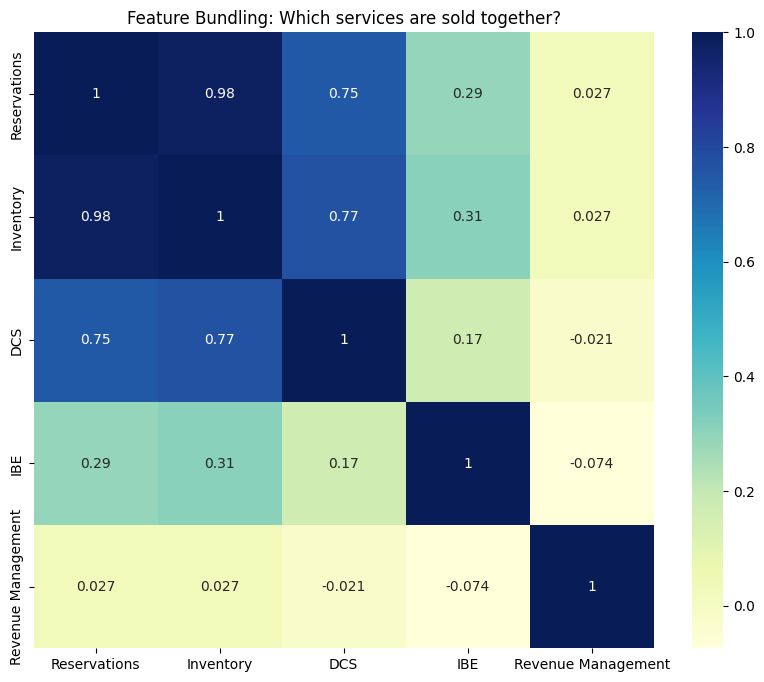

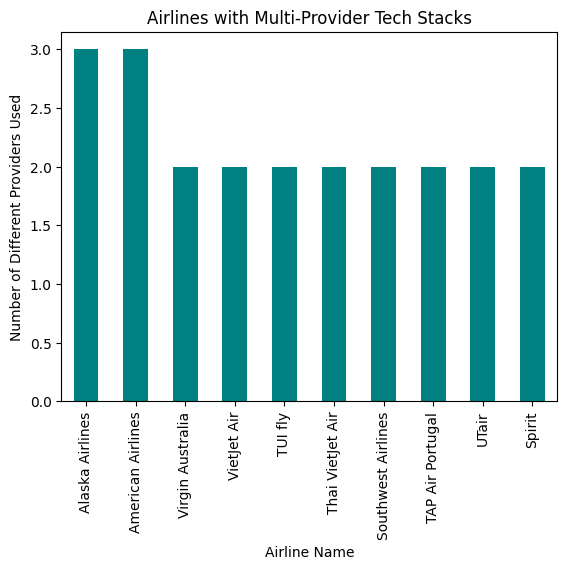

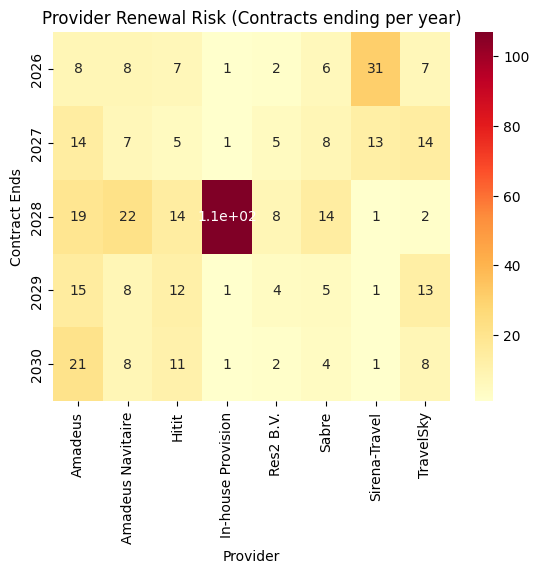

In [4]:
# 1. Feature Correlation Matrix
plt.figure(figsize=(10, 8))
features = ['Reservations', 'Inventory', 'DCS', 'IBE', 'Revenue Management']
sns.heatmap(df_all[features].corr(), annot=True, cmap='YlGnBu')
plt.title('Feature Bundling: Which services are sold together?')
plt.show()

# 2. Multi-Provider Strategy (Top 10 Airlines)
multi_source = df_all.groupby('Airline Name')['Provider'].nunique().sort_values(ascending=False).head(10)
multi_source.plot(kind='bar', color='teal', title='Airlines with Multi-Provider Tech Stacks')
plt.ylabel('Number of Different Providers Used')
plt.show()

# 3. Renewal Risk Heatmap (Next 5 Years)
risk_map = df_all.groupby(['Contract Ends', 'Provider']).size().unstack(fill_value=1)
sns.heatmap(risk_map.loc[2025:2030], annot=True, cmap='YlOrRd')
plt.title('Provider Renewal Risk (Contracts ending per year)')
plt.show()


[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


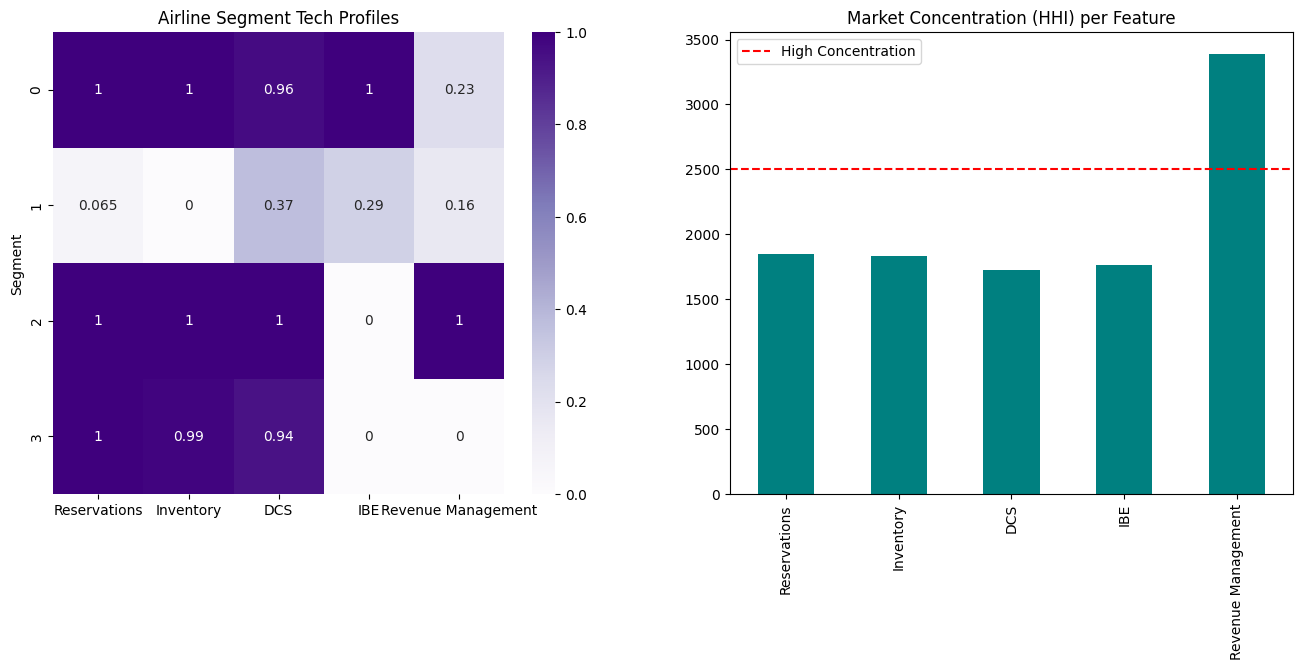

In [5]:
%pip install scikit-learn
from sklearn.cluster import KMeans
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming df_all is already loaded from your previous code
features = ['Reservations', 'Inventory', 'DCS', 'IBE', 'Revenue Management']

# --- 1. Machine Learning: Airline Clustering ---
# Group functionality by airline and segment them
airline_profile = df_all.groupby('Airline Name')[features].max()
kmeans = KMeans(n_clusters=4, random_state=42).fit(airline_profile)
airline_profile['Segment'] = kmeans.labels_

# --- 2. Market Concentration (HHI) ---
def calculate_hhi(feature_name):
    shares = df_all[df_all[feature_name] == 1]['Provider'].value_counts(normalize=True) * 100
    return (shares**2).sum()

hhi_scores = {f: calculate_hhi(f) for f in features}

# --- 3. Visualization ---
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Plot Segmentation
sns.heatmap(airline_profile.groupby('Segment')[features].mean(), annot=True, cmap='Purples', ax=ax[0])
ax[0].set_title('Airline Segment Tech Profiles')

# Plot HHI
pd.Series(hhi_scores).plot(kind='bar', ax=ax[1], color='teal')
ax[1].axhline(2500, color='red', linestyle='--', label='High Concentration')
ax[1].set_title('Market Concentration (HHI) per Feature')
plt.legend()
plt.show()

C:\Users\SG0708572\AppData\Local\Temp\ipykernel_21944\2916218446.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=provider_stickiness.values, y=provider_stickiness.index, palette='magma')


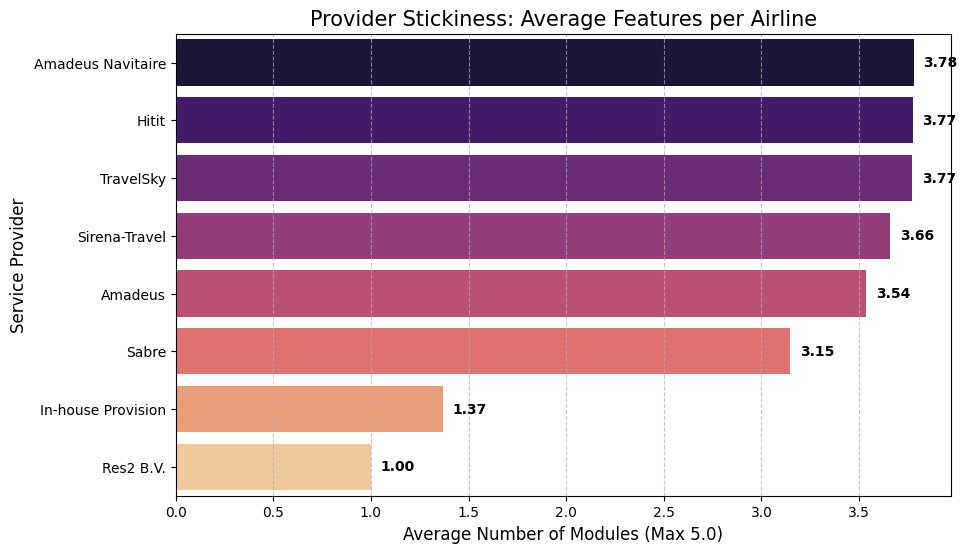

In [6]:
# 1. Define the functionalities to be measured
features = ['Reservations', 'Inventory', 'DCS', 'IBE', 'Revenue Management']

# 2. Calculate the number of features each airline uses per provider
# This creates a new column with a score from 0 to 5
df_all['Stickiness_Score'] = df_all[features].sum(axis=1)

# 3. Calculate the average stickiness for each provider
provider_stickiness = df_all.groupby('Provider')['Stickiness_Score'].mean().sort_values(ascending=False)

# 4. Visualize the results
plt.figure(figsize=(10, 6))
sns.barplot(x=provider_stickiness.values, y=provider_stickiness.index, palette='magma')

plt.title('Provider Stickiness: Average Features per Airline', fontsize=15)
plt.xlabel('Average Number of Modules (Max 5.0)', fontsize=12)
plt.ylabel('Service Provider', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Add numeric labels to the bars
for i, v in enumerate(provider_stickiness.values):
    plt.text(v + 0.05, i, f"{v:.2f}", color='black', va='center', fontweight='bold')

plt.show()

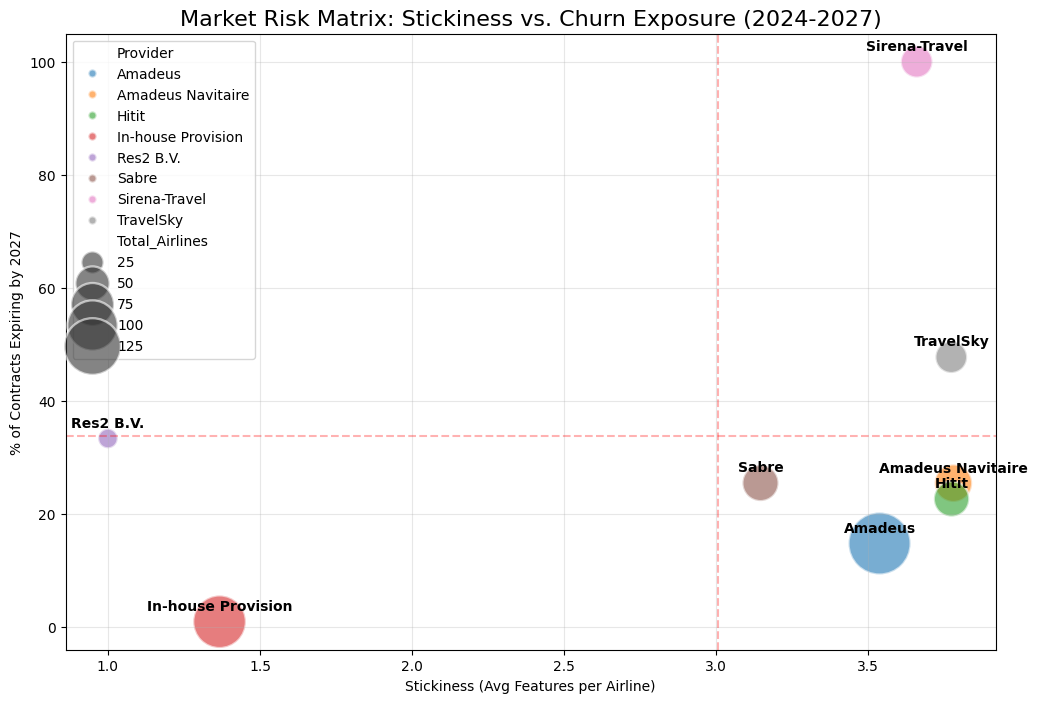

In [7]:

# 1. Prepare Data
features = ['Reservations', 'Inventory', 'DCS', 'IBE', 'Revenue Management']
df_all['feature_count'] = df_all[features].sum(axis=1)

# 2. Calculate Metrics
risk_summary = df_all.groupby('Provider').agg(
    Stickiness=('feature_count', 'mean'),
    Churn_Exposure=('Contract Ends', lambda x: (x <= 2027).mean() * 100),
    Total_Airlines=('Airline Name', 'count')
).reset_index()

# 3. Create the Scatter Plot
plt.figure(figsize=(12, 8))
plot = sns.scatterplot(
    data=risk_summary, 
    x='Stickiness', 
    y='Churn_Exposure', 
    size='Total_Airlines', 
    hue='Provider', 
    sizes=(200, 2000), 
    alpha=0.6
)

# 4. Add Quadrant Guidelines
plt.axvline(risk_summary['Stickiness'].mean(), color='red', linestyle='--', alpha=0.3)
plt.axhline(risk_summary['Churn_Exposure'].mean(), color='red', linestyle='--', alpha=0.3)

# Annotate provider names
for i in range(risk_summary.shape[0]):
    plt.text(risk_summary.Stickiness[i], risk_summary.Churn_Exposure[i]+2, 
             risk_summary.Provider[i], horizontalalignment='center', weight='bold')

plt.title('Market Risk Matrix: Stickiness vs. Churn Exposure (2024-2027)', fontsize=16)
plt.xlabel('Stickiness (Avg Features per Airline)')
plt.ylabel('% of Contracts Expiring by 2027')
plt.grid(True, alpha=0.3)
plt.show()